## Setting up environment for drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
from google.colab import userdata

config_path = userdata.get('CONFIG_PATH')

sys.path.append(config_path)

from config import BASE_PATH, DATA_PATH, SRC_PATH, SAVED_CHECKPOINTS_PATH

base_path = BASE_PATH

# Week 2 — Session 3: Baseline Classifiers

In the last session, we engineered **rich features** from our cleaned dataset:

Now it’s time to **build our first baseline models** to detect misinformation.

---

## What We’ll Do This Session

1. **Naïve Majority Class Classifier**
   - Always predicts the most frequent class.
   - Sets a baseline that any real model must beat.
1. **Simple Rule-Based Classifier**
   - Uses a very basic human-defined rule to separate classes.
   - Example: flag articles with clickbait phrases or excessive exclamations.
1. **Decision Trees**
   - Build interpretable tree-based models capturing decision rules.
   - Understand baseline tree performance before ensembling.
1. **Logistic Regression with TF-IDF**
   - Build a simple linear classifier using text only.
   - Use `TfidfVectorizer` to convert raw text into a sparse feature matrix.

---

## Why Baselines Matter

- They provide a **yardstick**: we’ll know if fancy models really add value.
- They help detect data leakage or unrealistic performance jumps.
- They illustrate how much signal is in simple features vs. complex ones.

---

By the end of this notebook, we’ll compare each baseline’s performance  
and decide what’s worth improving for the project.

## Libraries for Session 2

We’ll need the following core libraries:

- **pandas** → Load and inspect your cleaned dataset.
- **scikit-learn (`sklearn`)** → Build the baseline classifiers:
  - `DummyClassifier` → for the naïve majority class baseline.
  - `LogisticRegression` → for the first text-based model.
  - `TfidfVectorizer` → to convert raw text into TF-IDF features.
  - `train_test_split` → to split the data into training and testing.
  - `accuracy_score` → to evaluate performance.

---

These standard libraries make it easy to create, test, and compare simple models —  
setting you up for more advanced pipelines later!

In [ ]:
!pip install pandas scikit-learn

In [ ]:
!pip install {SRC_PATH}

Obtaining file:///content/drive/MyDrive/MASAID/AI_Project_Course/MisinformationPrivate/repo/src
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for misinformation_detection (pyproject.toml) ... done
  Created wheel for misinformation_detection: filename=misinformation_detection-1.0.0-0.editable-py3-none-any.whl size=3593 sha256=613b243498592969a3f55251bdc5bb5b69813856376119cb27daea2aa9695472
  Stored in directory: /tmp/pip-ephem-wheel-cache-h78f52cn/wheels/e3/cb/61/21e1431d117c3dd88d6cea8b2fc896103816321ea8ae8d3065
Successfully built misinformation_detection
  Attempting uninstall: misinformation_detection
    Found existing installation: misinformation_detection 1.0.0
    Uninstalling misinformation_detection-1.0.0:
      Successfully uninstalled misinformation_detection-1.0.0


In [ ]:
# All imports
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from misinformation_detection.data import load_fakenewsnet_from_dataframe

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Load the Cleaned FakeNewsNet Data

Before building any baseline models, we'll load the **fully cleaned** and **feature-engineered** version of our dataset without lemmatization.

This version includes:
- The raw ID and labels
- All the basic and advanced linguistic features
- One-hot encoded source domains
- Cleaned metadata columns

This makes sure we're starting from a consistent, reproducible version of the data pipeline.

In [ ]:
# Adjust the path if needed
data_path = base_path / Path("../../data/processed/fnn_features_all_columns.csv")

# Load the data
fnn_df = load_fakenewsnet_from_dataframe(data_path, verbose=True)

Loaded FakeNewsNet cleaned dataset with 13,892 rows
                     id                                              title  \
0  gossipcop-2493749932  Did Miley Cyrus and Liam Hemsworth secretly ge...   
1   gossipcop-941805037  Celebrities Join Tax March in Protest of Donal...   

  label dataset_source    source_domain  \
0  fake      gossipcop  dailymail.co.uk   
1  fake      gossipcop      variety.com   

                                     article_cleaned date_cleaned  \
0  congratulations might be in order for miley cy...   22/06/2018   
1  thousands are taking the streets to protest pr...   15/04/2017   

   source_domain.1 source_domain_grouped  source_Other  ...  \
0  dailymail.co.uk       dailymail.co.uk         False  ...   
1      variety.com           variety.com         False  ...   

   exclamation_count  stopword_count  has_clickbait  exclamation_ratio  \
0                  2             101          False           0.002717   
1                  0              71 

## 1. Naïve Majority Class Baseline

The simplest possible classifier is a **naïve baseline**:  
it always predicts the **majority class** found in the training data.

---

### Why This Matters

- This sets a **performance floor** — any real model should beat this!
- Helps us spot if our dataset is **imbalanced** (e.g., way more real than fake news).
- Forces us to compare the advanced models to a trivial benchmark.

---

### How It Works

- Use `sklearn.dummy.DummyClassifier` with `strategy="most_frequent"`.
- Fit it on our training set and evaluate accuracy on the test set.
- Compare this number to your rule-based and logistic regression baselines later.

---

**Example:**  
If 80% of the news is real, the majority class baseline will have ~80% accuracy — meaning any model that does worse is useless!

In [ ]:
# Define your target
y = fnn_df["label"]

# For DummyClassifier, X doesn’t matter — keep shape consistent
X = fnn_df.drop(columns="label")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}; y_train shape: {y_train.shape}")
print(f"X_train shape: {X_test.shape}; y_train shape: {y_test.shape}")

X_train shape: (11113, 39); y_train shape: (11113,)
X_train shape: (2779, 39); y_train shape: (2779,)


In [ ]:
# First let's manually write out the logic for figuring out the majority class

label_counts = y_train.value_counts(normalize=True)
print("Class distribution in training set:")
print(label_counts)

majority_class = label_counts.idxmax()
majority_percentage = label_counts.max()

print(
    f"\nIf we just guessed '{majority_class}' for every single article, we would be right {majority_percentage:.4%} of the time."
)
print("Compare this to the DummyClassifier score below!")

Class distribution in training set:
label
real    0.769189
fake    0.230811
Name: proportion, dtype: float64

If we just guessed 'real' for every single article, we would be right 76.9189% of the time.
Compare this to the DummyClassifier score below!


In [ ]:
def log_metrics(y_pred, y_true, classifier_label):
    """prints relevant output metrics"""
    # Predict and evaluate
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{classifier_label} accuracy: {accuracy:.4f}")


def plot_confusion_matrix(y_test, y_pred, labels, classifier_label):
    """plots confusion matrix"""
    cm = confusion_matrix(y_test, y_pred, labels=majority_clf.classes_)
    # Plot confusion matrix with seaborn heatmap
    fig = plt.figure(figsize=(6, 4))

    sns.heatmap(
        cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues"
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"{classifier_label} - Confusion Matrix")

    plt.tight_layout()
    return fig

Naïve Majority Classifier accuracy: 0.7693
Most frequent class: real


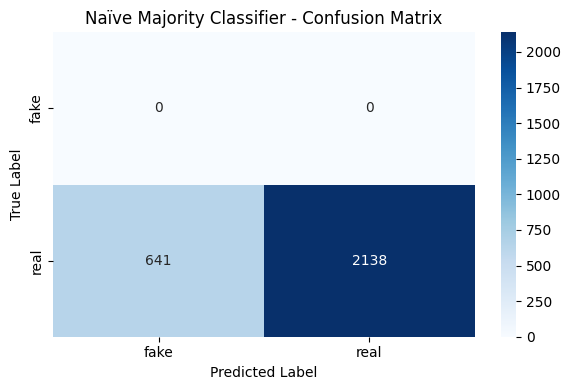

In [ ]:
# Create and fit the DummyClassifier
# For DummyClassifier, X doesn’t matter — keep shape consistent
majority_clf = DummyClassifier(strategy="most_frequent")
majority_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = majority_clf.predict(X_test)

log_metrics(y_pred, y_test, "Naïve Majority Classifier")
print(
    f"Most frequent class: {majority_clf.classes_[majority_clf.class_prior_.argmax()]}"
)

plot_confusion_matrix(
    y_pred, y_test, majority_clf.classes_, "Naïve Majority Classifier"
)
plt.show()

In [ ]:
# save the classifier
model_path = base_path / Path("../../saved_checkpoints/majority_clf.joblib")
joblib.dump(majority_clf, model_path)

['/content/drive/MyDrive/MASAID/AI_Project_Course/MisinformationPrivate/repo/week_2/sessions/../../saved_checkpoints/majority_clf.joblib']

## 2. Simple Rule-Based Classifier

Now that we have the **majority class baseline**,  
let’s see if a **human-defined rule** can do better.

Before creating our rule, we should check:
- **Which features look different for real vs. fake news?**
- Do things like word count, exclamation marks, or clickbait phrases show clear patterns?

By visualizing these, we can design a **simple rule** that tries to separate classes  
without any machine learning — just logic!

---

**Example:**  
If fake news tends to have shorter word counts and more clickbait,  
our rule might flag articles with low word count *and* clickbait phrases as fake.

---

### Recall

Recall the following statistics from our previous sessions:

### Average Article Length Insights

- We just plotted the **average word count** for **real vs. fake** news.
- This shows whether fake articles tend to be **shorter** or **longer** than real ones on average.
- If the difference is clear enough, we might use a simple **word count threshold** as part of your rule.

**Example Insight:**  
If fake news has a much lower average word count, we could flag articles with **very short length** as suspicious.

<Figure size 600x400 with 0 Axes>

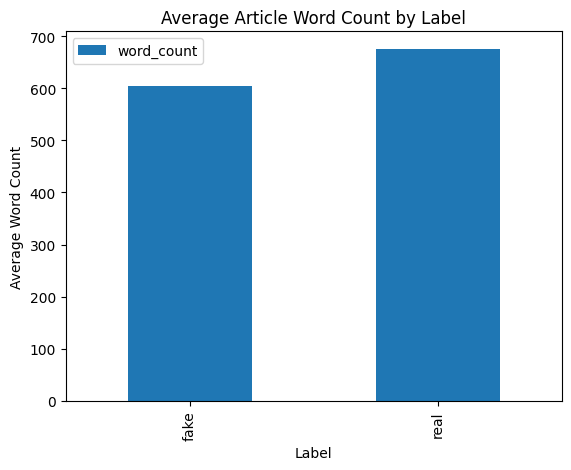

In [ ]:
plt.figure(figsize=(6, 4))
ax = (X_train.assign(label=y_train).groupby("label").agg({"word_count": "mean"})).plot(
    kind="bar"
)

ax.set_title("Average Article Word Count by Label")
ax.set_ylabel("Average Word Count")
ax.set_xlabel("Label")
plt.show()

### Check Specific Sources

In addition to text-based features, we saw that the **news source** itself can be a strong signal.

Here, we'll check if certain domains — like **`dailymail.co.uk`** and **`hollywoodlife.com`** —  
are more likely to publish fake vs. real news in the dataset.

This helps us see if a **source-based rule** could improve the baseline.

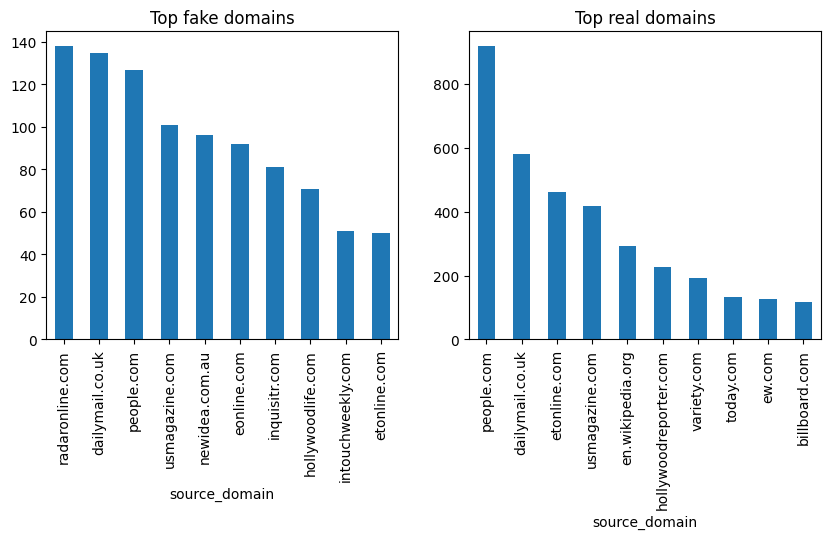

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, label in enumerate(["fake", "real"]):
    (
        X_train.loc[y_train == label]["source_domain"]
        .value_counts()
        .iloc[:10]
        .plot(kind="bar", ax=axes[i])
    )
    axes[i].set_title(f"Top {label} domains")
plt.show()

In [ ]:
# Pick your sources
sources_to_check = ["dailymail.co.uk", "hollywoodlife.com"]

print("Percentage of REAL vs FAKE within each source:\n")

for col in sources_to_check:
    # Get only rows where source_X == col
    subset = y_train.loc[X_train["source_domain"] == col]

    # Count how many real vs fake in that subset
    counts = subset.value_counts(normalize=True) * 100

    print(f"{col}:")
    print(f"  Real news: {counts.get('real', 0):.2f}%")
    print(f"  Fake news: {counts.get('fake', 0):.2f}%\n")

Percentage of REAL vs FAKE within each source:

dailymail.co.uk:
  Real news: 81.09%
  Fake news: 18.91%

hollywoodlife.com:
  Real news: 11.25%
  Fake news: 88.75%



After reviewing these key features, we can now build a **simple rule-based classifier**
to test whether human logic can beat our naïve baseline.

---

### How This Rule Works

- **If the source is `hollywoodlife.com` → predict FAKE**
- **If the source is `dailymail.co.uk` → predict REAL**
- **Otherwise:**
  - Use **word count** as a fallback:
    - If the article is longer than the midpoint between average real and fake word counts, predict REAL.
    - Otherwise, predict FAKE.

---

### Why This Matters

- Combines **source trustworthiness** and **text length** into a single, interpretable rule.
- Tests whether simple human insights can outperform a random guess.
- Provides a **baseline** to compare with machine learning models in the next step.

---

> **Pro Tip:** Always measure and visualize your rule’s performance — so you know if your intuition actually works!

In [ ]:
# Calculate your length threshold (mean of means)
real_mean_length = X_train.loc[y_train == "real"]["word_count"].mean()
fake_mean_length = X_train.loc[y_train == "fake"]["word_count"].mean()
length_threshold = (real_mean_length + fake_mean_length) / 2

print(f"Real mean word count: {real_mean_length:.2f}")
print(f"Fake mean word count: {fake_mean_length:.2f}")
print(f"Post length threshold: {length_threshold:.2f}")

Real mean word count: 675.26
Fake mean word count: 604.98
Post length threshold: 640.12


In [ ]:
def rule_based_predict(df):
    return np.where(
        df["source_domain"] == "hollywoodlife.com",
        "fake",
        np.where(
            df["source_domain"] == "dailymail.co.uk",
            "real",
            np.where(df["word_count"] > length_threshold, "real", "fake"),
        ),
    )


# Apply to the dataset
fnn_df["rule_pred"] = rule_based_predict(fnn_df)

Rule-Based Classifier accuracy: 0.4243
Most frequent class: real


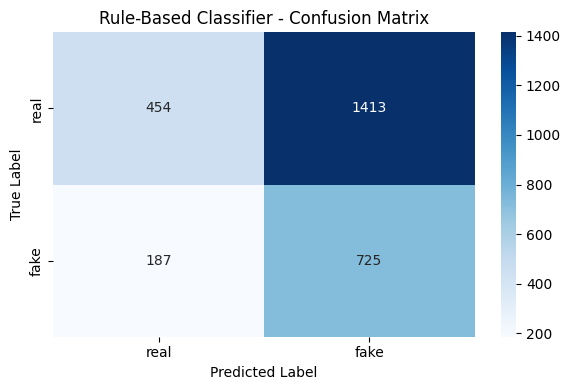

In [ ]:
y_pred = rule_based_predict(X_test)
log_metrics(y_pred, y_test, "Rule-Based Classifier")
print(
    f"Most frequent class: {majority_clf.classes_[majority_clf.class_prior_.argmax()]}"
)

plot_confusion_matrix(
    y_pred, y_test, labels=["real", "fake"], classifier_label="Rule-Based Classifier"
)
plt.show()

In [ ]:
config_path = base_path / Path("../../saved_checkpoints/rule_based_config.json")

config = {
    "fake_sources": ["hollywoodlife.com"],
    "real_sources": ["dailymail.co.uk"],
    "length_threshold": length_threshold,
}
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

## Results: Rule-Based Classifier Performance

After applying our simple rule:
- The accuracy is **lower than expected** — even worse than the naïve baseline.
- The confusion matrix shows that the rule **misclassifies many real or fake articles**.

---

### Why Did It Fail?

- The **source signals** we chose are not dominant enough: only a small fraction of articles come from `hollywoodlife.com` or `dailymail.co.uk`.
- The **word count threshold** is too crude — many fake articles can be long, and real articles can be short.
- Real-world fake news is often crafted to **mimic real news structure**, so length alone is not a reliable signal.

---

### Key Lesson

- Human rules based on simple heuristics may fail when patterns are subtle or noisy, as we see here.

- However, they give us an important measuring stick. Sometimes, simple rule-based methods are all that’s needed for a specific problem. They save on compute, make interpretability compliance easy, and require zero training data.

- Since our rule failed to beat the baseline, we know we need machine learning models with richer features (like TF-IDF) to detect the complex signals in this dataset.

---

In [ ]:
(
    X_train.assign(label=y_train)
    .assign(real=lambda x: x["label"] == "real")
    .groupby("source_domain", as_index=False)
    .agg(mean_real_posts=("real", "mean"), count=("real", "count"))
    .loc[lambda x: x["count"] > 100]
    .sort_values(by="mean_real_posts", ascending=False)
)

,source_domain,mean_real_posts,count
869,today.com,0.970803,137
378,hollywoodreporter.com,0.912000,250
269,etonline.com,0.902534,513
857,thewrap.com,0.881890,127
204,deadline.com,0.880734,109
653,people.com,0.878469,1045
919,variety.com,0.869369,222
358,harpersbazaar.com,0.867257,113
119,bustle.com,0.866667,105
250,en.wikipedia.org,0.861765,340


Now we can just load this lemmataized dataset instead of rerunning lemmatization which would be time consuming

## 3. TF-IDF + Logistic Regression (Lemmatized)

We will now use the lemmatized version of our text to build a **Logistic Regression model**  
using a TF-IDF vectorizer to turn the processed text into features.

---

### Why This Matters

- TF-IDF converts text into **weighted word vectors**, giving more importance to unique words.
- Logistic Regression is a simple yet powerful baseline for text classification.
- Lemmatization ensures you treat **similar words as the same**, improving generalization.

---

### What You’ll See

- Model accuracy on the test set.
- A confusion matrix to see how well real vs. fake articles are separated.

This gives you a strong baseline to compare to more advanced models later!

Load the lemmatized version of the dataset

In [ ]:
# Load your saved dataset with the lemmatized column
fnn_df = load_fakenewsnet_from_dataframe(
    data_path.with_name("fnn_lemmatized.csv"), verbose=True
)

Loaded FakeNewsNet cleaned dataset with 13,892 rows
                     id                                              title  \
0  gossipcop-2493749932  Did Miley Cyrus and Liam Hemsworth secretly ge...   
1   gossipcop-941805037  Celebrities Join Tax March in Protest of Donal...   

  label dataset_source    source_domain  \
0  fake      gossipcop  dailymail.co.uk   
1  fake      gossipcop      variety.com   

                                     article_cleaned date_cleaned  \
0  congratulations might be in order for miley cy...   22/06/2018   
1  thousands are taking the streets to protest pr...   15/04/2017   

   source_domain.1 source_domain_grouped  source_Other  ...  stopword_count  \
0  dailymail.co.uk       dailymail.co.uk         False  ...             101   
1      variety.com           variety.com         False  ...              71   

   has_clickbait  exclamation_ratio  stopword_ratio  flesch_reading_ease  \
0          False           0.002717        0.137228          

In [ ]:
# === 1. Prepare your data ===
# Note: use the same train / test split as the other models
train_idx = X_train.index
test_idx = X_test.index

train_text = fnn_df["article_lemmatized"].iloc[train_idx]
test_text = fnn_df["article_lemmatized"].iloc[test_idx]

print(f"X_train shape: {train_text.shape}; y_train shape: {y_train.shape}")
print(f"X_train shape: {test_text.shape}; y_train shape: {y_test.shape}")

X_train shape: (11113,); y_train shape: (11113,)
X_train shape: (2779,); y_train shape: (2779,)


In [ ]:
# === 2. TF-IDF Vectorization ===
# Loading the vectorizer from last session:
vectorizer_path = base_path / Path("../../saved_checkpoints/tfidf_vectorizer.joblib")
vectorizer = joblib.load(vectorizer_path)
X_train_tfidf = vectorizer.fit_transform(train_text)
X_test_tfidf = vectorizer.transform(test_text)

# === 3. Train Logistic Regression ===
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_tfidf, y_train)

# === 4. Predict and evaluate ===
y_pred = clf.predict(X_test_tfidf)
log_metrics(y_pred, y_test, "TF-IDF Logistic Regression")

plot_confusion_matrix(
    y_pred,
    y_test,
    labels=["real", "fake"],
    classifier_label="TF-IDF Logistic Regression",
)
plt.show()
# Save the model

joblib.dump(clf, base_path / Path("../../saved_checkpoints/fnn_logreg.joblib"))
joblib.dump(
    vectorizer, base_path / Path("../../saved_checkpoints/fnn_tfidf_vectorizer.joblib")
)

## TF-IDF Logistic Regression: First Look

The **TF-IDF + Logistic Regression** model achieved:  
- **Accuracy:** ~80% — a solid improvement over the dummy and rule-based baselines.

---

### What This Tells Us

- The model captures meaningful patterns in the text beyond simple rules.
- Accuracy looks promising, but accuracy alone can be misleading — especially with class imbalance.
- The confusion matrix already hints that while precision for fake news is decent, recall is much lower — meaning it misses a lot of fake articles.


## 4. Decision Tree Classifier (Lemmatized)

Now we'll build a **Decision Tree model** to classify real vs. fake articles.

---

### Why This Matters

- Decision trees create **interpretable rules** for classification based on feature thresholds.
- They capture nonlinear relationships and feature interactions.
- Limiting tree depth helps **prevent overfitting**, making them flexible yet understandable.

---

### What We’ll See

- Performance metrics including accuracy, precision, recall, and F1-score.
- A confusion matrix visualizing classification errors.
- A sample visualization of the tree’s structure to understand key decision splits.

This baseline will help us understand how a single, interpretable model performs before moving to ensembles or more complex classifiers!


In [ ]:
# === 1. Reuse the TF-IDF data from the previous section ===
# We already split the data and vectorized it in Step 3.
# We can just pass those existing matrices (X_train_tfidf, X_test_tfidf) into the tree.

# === 2. Train Decsision Tree Classifier ===
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train_tfidf, y_train)

# === 3. Predict and evaluate ===
tree_preds = tree_clf.predict(X_test_tfidf)
y_pred = clf.predict(X_test_tfidf)
log_metrics(tree_preds, y_test, "TF-IDF Decision Tree")

plot_confusion_matrix(
    tree_preds, y_test, labels=["real", "fake"], classifier_label="TF-IDF Decision Tree"
)
plt.show()

joblib.dump(
    tree_clf, base_path / Path("../../saved_checkpoints/decision_tree_model.joblib")
)
joblib.dump(
    vectorizer,
    base_path / Path("../../saved_checkpoints/decision_tree_vectorizer.joblib"),
)

## Decision Tree Classifier — Results & Insights

Our simple **Decision Tree** has been similarly trained with TF-IDF as logistic regression was.  
Here’s what we can see from the results:

- **Accuracy:** ~78%  
The tree achieves reasonable accuracy but struggles with recall for fake news — showing that deeper splits or more advanced ensembles may help.

---

### **Confusion Matrix**
The confusion matrix shows:
- Many real news items correctly identified.
- Some fake news articles still being predicted as real.

---

### **Key Takeaway**
Decision Trees are:
- Easy to interpret and visualize.
<!-- - Prone to **overfitting** if deep, but here you controlled depth. -->
- Can serve as a baseline for comparing more robust ensembles later in week 3 like Random Forests or XGBoost.


---

### What’s Next

In **Session 3**, we'll:
- Calculate **precision**, **recall**, **F1-score**, and **ROC/PR curves** to get a clearer performance picture.
- Compare these metrics across your baseline models.
- Analyze where the model makes mistakes and why.

---

For now: you have a **stronger baseline** and a solid foundation for deeper evaluation!

## Back to our package!

> 📝: This content will be placed into src

We can now package all the training and loading code into neat functions in our package.

Let's also create this helper function that produces our dataset for quick use in later notebooks

In [ ]:
def prepare_text_structured_features_full(
    csv_path,
    text_column="article_lemmatized",
    target_column="label",
    columns_to_exclude=None,
    test_size=0.2,
    random_state=42,
    max_tfidf_features=100,
    verbose=False,
):
    """
    Loads data, splits text & full DataFrame, applies TF-IDF, then drops excluded columns.

    This version keeps all columns until after the split, then drops excluded columns.

    Returns combined structured+text train/test, original full splits, y splits, and vectorizer.
    """

    # Load data
    df = load_fakenewsnet_from_dataframe(csv_path)
    if verbose:
        print(f"Loaded shape: {df.shape}")
        print(df.columns.tolist())

    # Target & text
    X_text = df[text_column]
    y = df[target_column]

    # Default columns to exclude
    if columns_to_exclude is None:
        columns_to_exclude = [
            "id",
            "title",
            "label",
            "dataset_source",
            "source_domain",
            "article_cleaned",
            "date_cleaned",
            "source_domain_grouped",
            "article_lemmatized",
            "rule_pred",
        ]

    # Split — keep all columns initially
    (
        X_text_train,
        X_text_test,
        X_structured_train_full,
        X_structured_test_full,
        y_train,
        y_test,
    ) = train_test_split(
        X_text, df, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # TF-IDF
    vectorizer = TfidfVectorizer(max_features=max_tfidf_features, stop_words="english")
    X_train_tfidf = vectorizer.fit_transform(X_text_train)
    X_test_tfidf = vectorizer.transform(X_text_test)

    tfidf_train_df = pd.DataFrame(
        X_train_tfidf.toarray(),
        columns=vectorizer.get_feature_names_out(),
        index=X_structured_train_full.index,
    )

    tfidf_test_df = pd.DataFrame(
        X_test_tfidf.toarray(),
        columns=vectorizer.get_feature_names_out(),
        index=X_structured_test_full.index,
    )

    # Drop excluded columns AFTER split
    X_structured_train = X_structured_train_full.drop(columns=columns_to_exclude)
    X_structured_test = X_structured_test_full.drop(columns=columns_to_exclude)

    # Combine
    X_train_combined = pd.concat([tfidf_train_df, X_structured_train], axis=1)
    X_test_combined = pd.concat([tfidf_test_df, X_structured_test], axis=1)

    if verbose:
        # Inspect
        print(f"Structured shape after drop: {X_structured_train.shape}")
        print(f"Combined training shape: {X_train_combined.shape}")
        print(f"Combined test shape: {X_test_combined.shape}")

    return (
        X_train_combined,
        X_test_combined,
        X_structured_train_full,
        X_structured_test_full,
        y_train,
        y_test,
        vectorizer,
    )

### Now let's move on to our models!

Let's build a class for each model with functionalities to:
- Setup/load the model (constructor)
- Train the model
- Save the model
- Predict using the model
- Any additional function each model might need

We will continue to add to these classes throughout the sessions.

In [ ]:
import joblib
from sklearn.dummy import DummyClassifier


class MajorityClassBaseline:
    def __init__(self, strategy="most_frequent", model_path=None, dummy_params=None):
        """
        Initialize DummyClassifier to always predict the majority class.
        You can provide param dict or load from checkpoint.
        """
        if model_path:
            self.model = joblib.load(model_path)
        else:
            default_args = {"strategy": strategy}
            self.model = DummyClassifier(**(dummy_params or default_args))

    def fit(self, X, y):
        """
        Fit the dummy classifier on training labels.
        X is only used to match shape API compatibility.
        """
        self.model.fit(X, y)

    def predict(self, X):
        """
        Predict with the dummy classifier.
        X shape matches fit; values ignored.
        """
        return self.model.predict(X)

    def most_frequent_class(self):
        """
        Returns the value of the majority class after fitting.
        """
        return self.model.classes_[self.model.class_prior_.argmax()]

    def save(self, model_path):
        """
        Save trained dummy classifier.
        """
        joblib.dump(self.model, model_path)

    def load(self, model_path):
        """
        Load the dummy classifier from disk.
        """
        self.model = joblib.load(model_path)

In [ ]:
import pandas as pd
import json


class RuleBasedClassifier:
    def __init__(
        self,
        fake_sources=None,
        real_sources=None,
        length_threshold=None,
        config_path=None,
    ):
        """
        Initialize the classifier with domain and length heuristics.
        You can set parameters directly or load from a JSON config.
        """
        if config_path:
            with open(config_path, "r") as f:
                config = json.load(f)
            self.fake_sources = config.get("fake_sources", ["hollywoodlife.com"])
            self.real_sources = config.get("real_sources", ["dailymail.co.uk"])
            self.length_threshold = config.get("length_threshold", 638)
        else:
            self.fake_sources = fake_sources if fake_sources else ["hollywoodlife.com"]
            self.real_sources = real_sources if real_sources else ["dailymail.co.uk"]
            self.length_threshold = (
                length_threshold if length_threshold is not None else 638
            )

    def fit(self, X, y=None):
        """
        Fitting not required for rule-based classifier,
        but included for API compatibility.
        """
        pass

    def predict_row(self, row):
        """
        Apply rules to predict label for a single data row (dict or pandas Series).
        """
        source = row.get("source_domain", None)
        wordcount = row.get("word_count", None)
        if source in self.fake_sources:
            return "fake"
        elif source in self.real_sources:
            return "real"
        else:
            if wordcount is not None and wordcount > self.length_threshold:
                return "real"
            else:
                return "fake"

    def predict(self, X_df):
        """
        Predict labels for the input DataFrame using rules.
        """
        return X_df.apply(self.predict_row, axis=1)

    def save_config(self, config_path):
        """
        Save current rule parameters to a config JSON.
        """
        config = {
            "fake_sources": self.fake_sources,
            "real_sources": self.real_sources,
            "length_threshold": self.length_threshold,
        }
        with open(config_path, "w") as f:
            json.dump(config, f, indent=2)

    def load_config(self, config_path):
        """
        Load rule parameters from config JSON.
        """
        with open(config_path, "r") as f:
            config = json.load(f)
        self.fake_sources = config.get("fake_sources", ["hollywoodlife.com"])
        self.real_sources = config.get("real_sources", ["dailymail.co.uk"])
        self.length_threshold = config.get("length_threshold", 638)

In [ ]:
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer


class LogisticRegressionBaseline:
    def __init__(
        self,
        max_iter=1000,
        random_state=42,
        vectorizer_path=None,
        model_path=None,
        vectorizer_params=None,
        lr_params=None,
    ):
        """
        Initialize LogisticRegression and TfidfVectorizer.
        You can provide parameter dicts or pass paths to pretrained objects.
        """
        # Set up TF-IDF vectorizer
        if vectorizer_path:
            self.vectorizer = joblib.load(vectorizer_path)
        else:
            default_vec = {"max_features": 100, "stop_words": "english"}
            self.vectorizer = TfidfVectorizer(**(vectorizer_params or default_vec))

        # Set up logistic regression model
        if model_path:
            self.model = joblib.load(model_path)
        else:
            default_lr = {"max_iter": max_iter, "random_state": random_state}
            self.model = LogisticRegression(**(lr_params or default_lr))

    def fit(self, X_text, y):
        """
        Fit model to training data.
        """
        X_vec = self.vectorizer.fit_transform(X_text)
        self.model.fit(X_vec, y)

    def transform(self, X_text):
        """
        Transform new text data using the trained vectorizer.
        """
        return self.vectorizer.transform(X_text)

    def predict(self, X_text):
        """
        Predict labels for new text.
        """
        X_vec = self.transform(X_text)
        return self.model.predict(X_vec)

    def save(self, model_path, vectorizer_path):
        """
        Save model and vectorizer to disk.
        """
        joblib.dump(self.model, model_path)
        joblib.dump(self.vectorizer, vectorizer_path)

    def load(self, model_path, vectorizer_path):
        """
        Load model and vectorizer from disk.
        """
        self.model = joblib.load(model_path)
        self.vectorizer = joblib.load(vectorizer_path)

In [ ]:
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer


class DecisionTreeBaseline:
    def __init__(
        self,
        max_depth=5,
        random_state=42,
        vectorizer_path=None,
        model_path=None,
        vectorizer_params=None,
        tree_params=None,
    ):
        """
        Initialize a DecisionTreeClassifier and TfidfVectorizer for text classification.

        You can provide params for vectors/tree or pass paths to pretrained objects.
        """
        # Load vectorizer or setup from params
        if vectorizer_path:
            self.vectorizer = joblib.load(vectorizer_path)
        else:
            self.vectorizer = TfidfVectorizer(
                **(vectorizer_params or {"max_features": 100, "stop_words": "english"})
            )

        # Load model or setup from params
        if model_path:
            self.model = joblib.load(model_path)
        else:
            tree_args = (
                tree_params
                if tree_params
                else {"max_depth": max_depth, "random_state": random_state}
            )
            self.model = DecisionTreeClassifier(**tree_args)

    def fit(self, X_text, y):
        """
        Fit model to input data (text and labels).
        Automatically fits TF-IDF vectorizer first if needed.
        """
        X_vec = self.vectorizer.fit_transform(X_text)
        self.model.fit(X_vec, y)

    def transform(self, X_text):
        """
        Transform text with the vectorizer.
        """
        return self.vectorizer.transform(X_text)

    def predict(self, X_text):
        """
        Predict on input text.
        """
        X_vec = self.transform(X_text)
        return self.model.predict(X_vec)

    def save(self, model_path, vectorizer_path):
        """
        Save the trained model and vectorizer.
        """
        joblib.dump(self.model, model_path)
        joblib.dump(self.vectorizer, vectorizer_path)

    def load(self, model_path, vectorizer_path):
        """
        Load model and vectorizer from disk.
        """
        self.model = joblib.load(model_path)
        self.vectorizer = joblib.load(vectorizer_path)

## [💎 Additional Credit] Pytest

Check out the tests folder to see how we test these edits